# Classical TimeSeries Decomposition

In [1]:
import pandas as pd
import datetime
from statsmodels.tsa.seasonal import seasonal_decompose
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
stock_data = yf.download("AAPL",start='2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-08-18,310.029999,311.489990,305.739990,307.579987,53424500
2026-08-19,316.829987,319.279999,309.600006,310.140015,50505600
2026-08-20,311.299988,320.279999,310.649994,317.459991,40959200
2026-08-21,309.350006,312.380005,307.010010,312.049988,46876800
2026-08-24,310.339996,313.359985,309.970001,311.470001,34655000


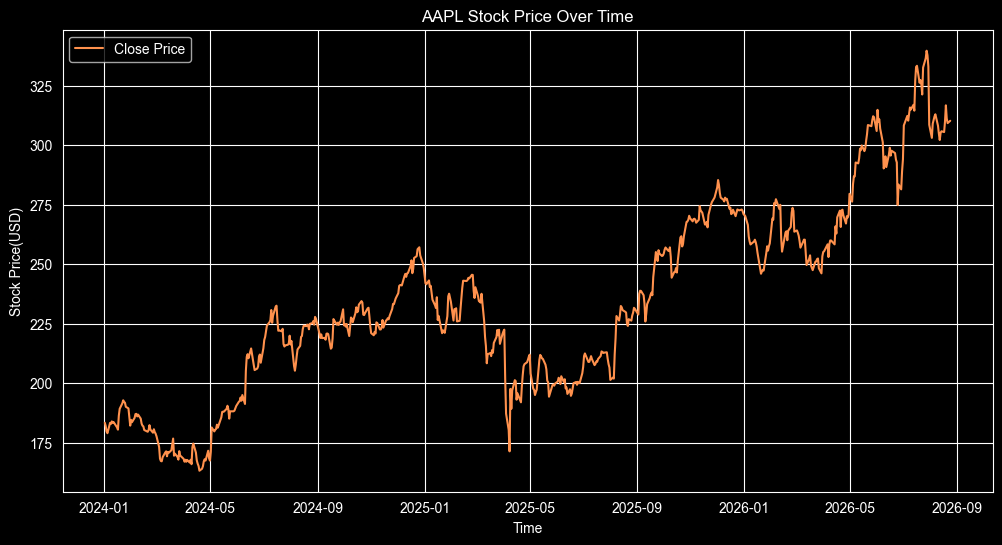

In [4]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index,stock_data['Close'],label='Close Price' , color = '#FF914D')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Time')
plt.ylabel('Stock Price(USD)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
decomposition_additive = seasonal_decompose(stock_data['Close'],model='additive',period=30)

trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

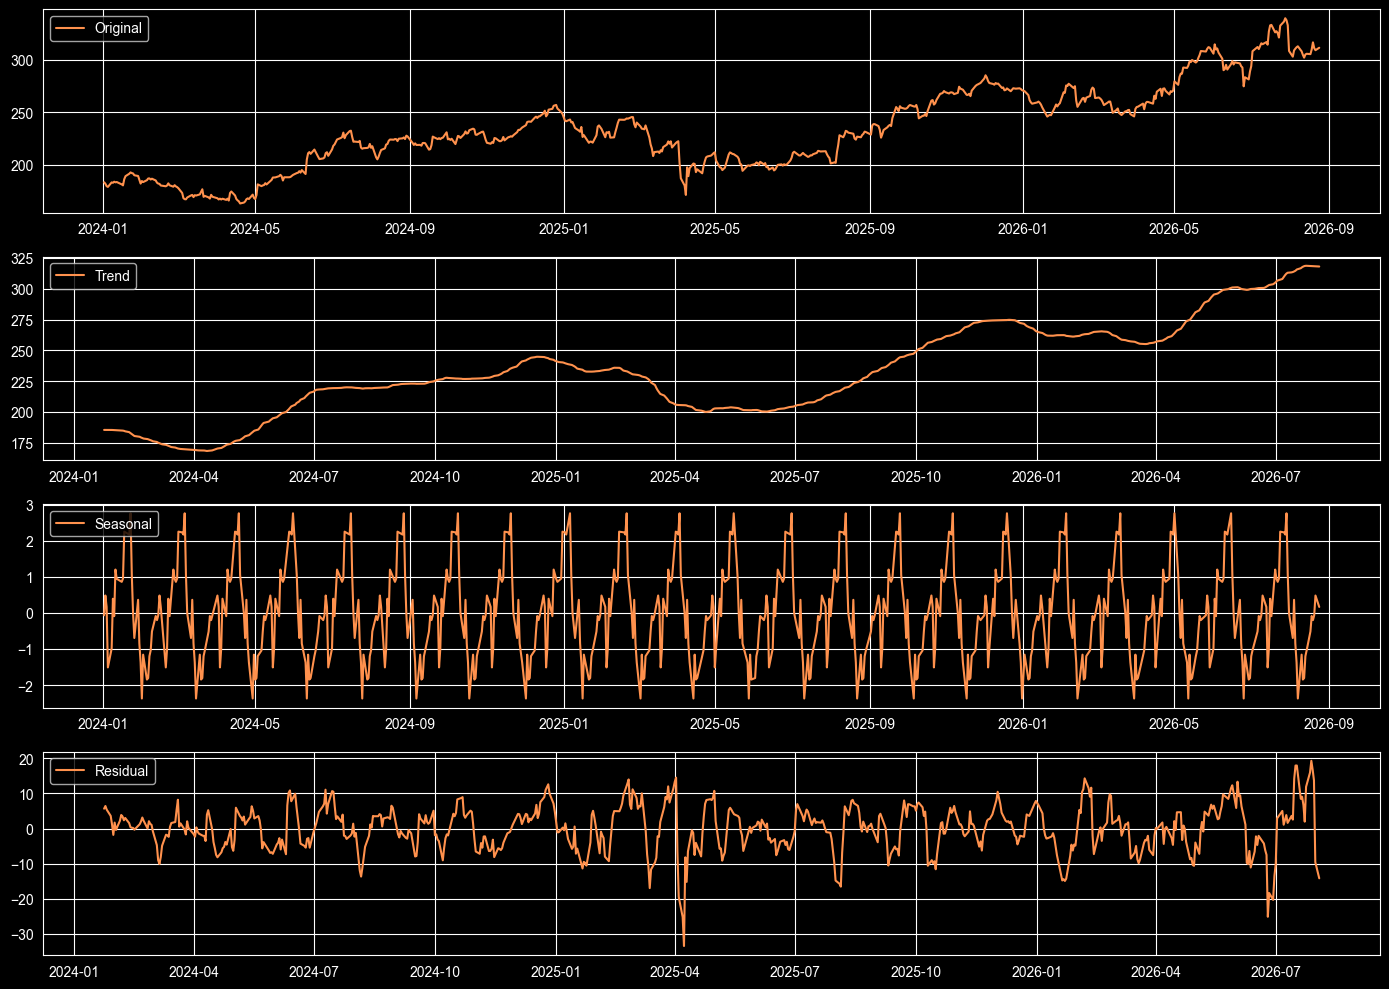

In [6]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(stock_data['Close'],label='Original' , color = '#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_additive,label='Trend' , color = '#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_additive,label='Seasonal' , color = '#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_additive,label='Residual' , color = '#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


# STL Decomposition using LOESS

*LOESS : Locally Estimated ScatterPlot Smoothing*

* Handle outlier in Timeseries data
* Variety in Seasonal Pattern
* only handle additive model

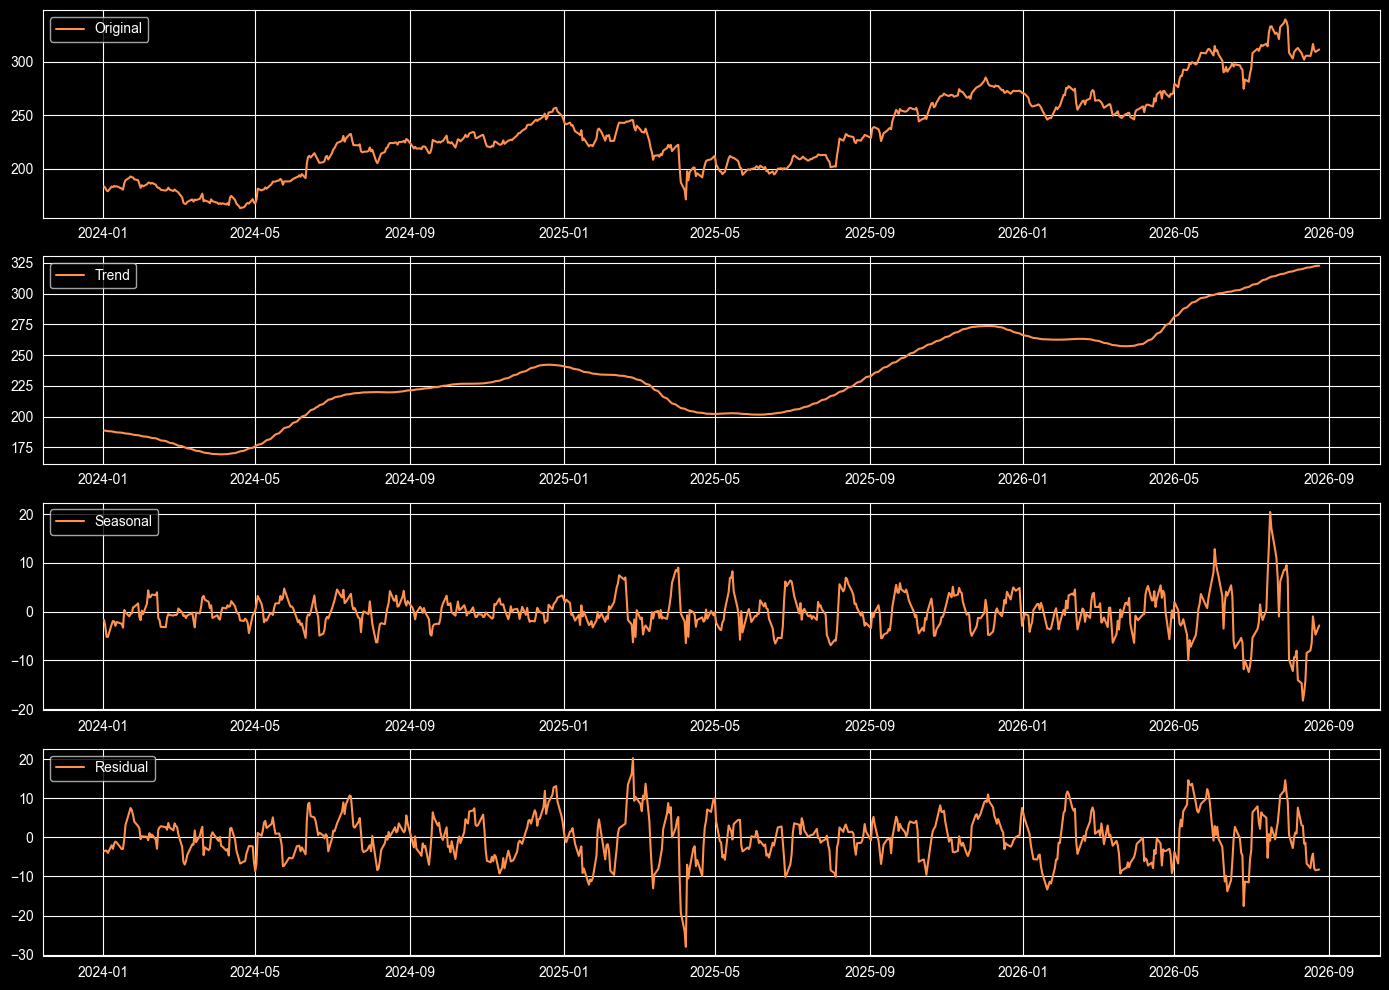

In [7]:
from statsmodels.tsa.seasonal import STL

# Perform STL Decomposition
stl = STL(stock_data['Close'],period=30)
result = stl.fit()

# Plot the decomposition components
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(result.observed,label='Original',color = '#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend,label='Trend',color = '#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal,label='Seasonal',color = '#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid,label='Residual',color = '#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Stationarity

* when mean,variance,auto correlation is constant overtime
* makes prediction easier, because it assumes same statistical properties throughout the time.
* Forecasting Modules requires a stationary data

Types of Stationarity
* Weak Stationarity : Constant mean,variance and auto correlation. Joint Distribution can change.
* Strict Stationarity : should have properties of Weak Stationarity and joint distribution remain unchanged when shifted along any time period.

Testing for Stationarity

* Weak Stationarity : ADF Test , KPSS Test

*ADF Test* : presence of unit root - non stationary trend

*Null Hypothesis* $H_0$ --> Data has a unit root(non stationary)

*Alternative Hypothesis*  $H_l$ --> stationary

*Decision Criteria* : p<0.05 --> stationary
ADF statistic < critical value, we reject the $H_0$

*KPSS Test* : fits a constant mean model on the data. Measures the variance of cumulative sum of residuals.

*Null Hypothesis* $H_0$ --> stationary

*Alternative Hypothesis*  $H_l$ --> non stationary

*Decision Criteria* : p<0.05 --> non stationary
KPSS statistic > critical value, we reject the $H_0$

*Strict Test* --> KS Test

compare the cumulative distribution functions of two samples

*Decision Criteria* : p > 0.05 --> No difference in distribution
KPSS statistic > critical value, we reject the $H_0$

# Stationary Test

In [8]:
from statsmodels.tsa.stattools import adfuller

#Perform the Augmented Dickey-Fuller test
adf_test = adfuller(stock_data['Close'])

print('ADF Test Results:')
print(f'ADF Statistics: {round(adf_test[0],3)}')
print(f'p-value: {round(adf_test[1],3)}')
print('Critical Values:')
for key,value in adf_test[4].items():
    print(f'{key}: {round(value,3)}')

ADF Test Results:
ADF Statistics: -0.748
p-value: 0.834
Critical Values:
1%: -3.44
5%: -2.866
10%: -2.569


*The above data is non stationary data since p-value > 0.05*

In [9]:
from statsmodels.tsa.stattools import kpss

# Perform KPSS Test
kpss_test = kpss(stock_data['Close'],regression='ct') # 'c' for constant(level stationarity) 'ct' for trend

print('KPSS Test Results:')
print(f'KPSS Statistics: {round(kpss_test[0],2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key,value in kpss_test[3].items():
    print(f'{key}: {value}')

KPSS Test Results:
KPSS Statistics: 0.32
p-value: 0.01
Critical Values:
10%: 0.119
5%: 0.146
2.5%: 0.176
1%: 0.216


*The above data is non stationary data since p-value < 0.05*

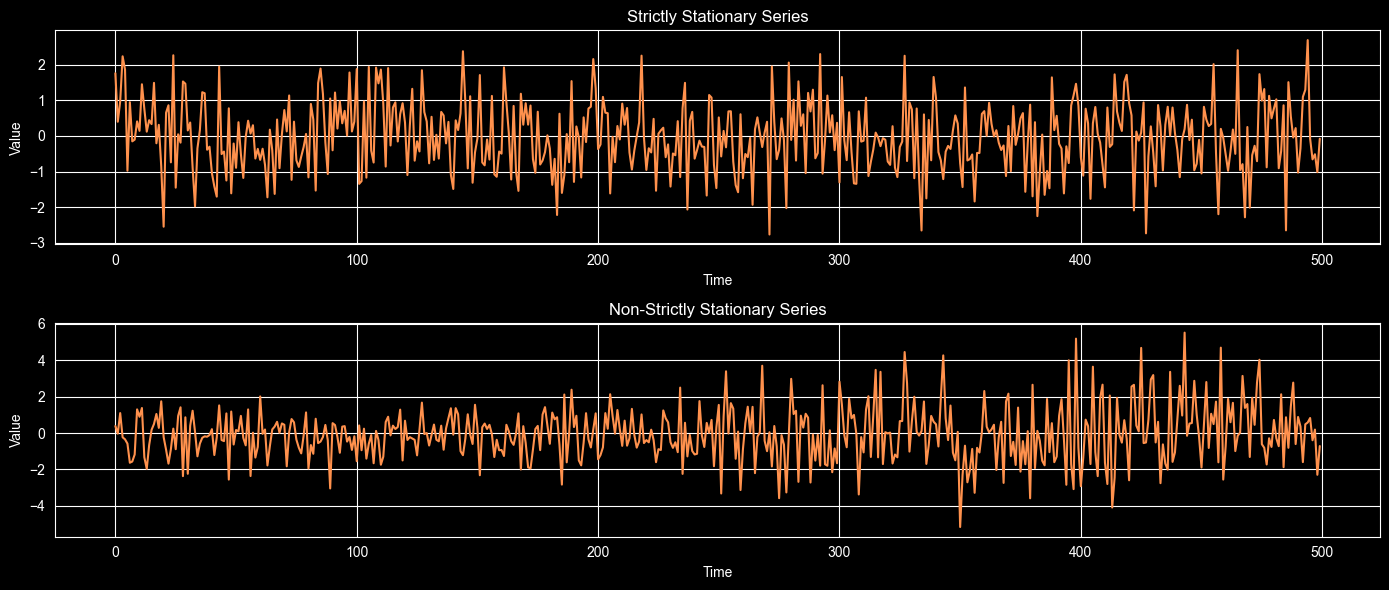

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating Synthetic Data for demonstration
np.random.seed(0)
n = 500

# Strictly Stationary series : normally distributed random noise
strict_stationary_series = np.random.normal(0,1,n)

# Non-Strictly Stationary series : changing variance
non_strict_stationary_series = np.concatenate([
    np.random.normal(0,1,n // 2),
    np.random.normal(0,2,n // 2)
])

# Function to split the series into two halves and perform the K-S Test

def ks_test_stationarity(series):
    split = len(series)//2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat,p_value = ks_2samp(series_first_half,series_second_half)
    return stat,p_value

# Perform K-S test on strictly stationary series
ks_stat_strict,ks_pvalue_strict = ks_test_stationarity(strict_stationary_series)

# Perform K-S test on non-strictly stationary series
ks_stat_non_strict,ks_pvalue_non_strict = ks_test_stationarity(non_strict_stationary_series)

# Plotting the series
plt.figure(figsize=(14,6))

# Strictly stationary series
plt.subplot(2, 1, 1)
plt.plot(strict_stationary_series,color = '#FF914D')
plt.title("Strictly Stationary Series")
plt.xlabel("Time")
plt.ylabel("Value")

# Non-strictly stationary series
plt.subplot(2, 1, 2)
plt.plot(non_strict_stationary_series,color = '#FF914D')
plt.title("Non-Strictly Stationary Series")
plt.xlabel("Time")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# Making a TimeSeries Stationary

**1. Differencing**

$y_t$ = current value

$y_t-1$ = past observed value

First Order : $y_t^{'}$ = $y_t$ - $y_{t-1}$

Second Order : $y_t^{''}$ = $y_t^{'}$ - $y_{t-1}^{'}$

**2. Transformation** : stabilizes the variance of time series data

* Logarithmic - log of the data
* Power - $y_t$ --> sqrt($y_t$)
* Box-Cox - Combination of power and logarithmic transformation

**3. De-trending** : removing trend component

* Linear Detrending
* Moving Average Detrending

**4. Seasonal Adjustment** : removing seasonal component using STL decomposition


# Making Data Stationary

In [11]:
# Performing ADF and KPSS tests

def adf_test(series):
    result = adfuller(series)
    print("ADF Statistics:", result[0])
    print("p-value",result[1])
    for key,value in result[4].items():
        print("Critical Value (%s) : %.3f" % (key,value))

def kpss_test(series):
    result = kpss(series,regression='c')
    print("KPSS Statistics:", result[0])
    print("p-value",result[1])
    for key,value in result[3].items():
        print("Critical Value (%s) : %.3f" % (key,value))

In [12]:
prices = stock_data['Close']

In [13]:
adf_test(prices)

ADF Statistics: -0.7477027964904381
p-value 0.8340036294976834
Critical Value (1%) : -3.440
Critical Value (5%) : -2.866
Critical Value (10%) : -2.569


In [14]:
prices

Ticker,AAPL
Date,
2024-01-02,183.404022
2024-01-03,182.030777
2024-01-04,179.718948
2024-01-05,178.997726
2024-01-08,183.324997
...,...
2026-08-18,310.029999
2026-08-19,316.829987
2026-08-20,311.299988


In [15]:
prices_diff = prices.diff()

In [16]:
print(prices.shape)

(663, 1)


In [17]:
import numpy as np
from scipy import stats

# Log Transformation
prices_log = np.log(prices)

# Square Root Transformation
prices_sqrt = np.sqrt(prices)

# Box-Cox Transformation
# Note Box-Cox requires all positive Values
prices = prices.squeeze()
prices_boxcox,lam = stats.boxcox(prices)

In [18]:
prices_log

Ticker,AAPL
Date,
2024-01-02,5.211691
2024-01-03,5.204176
2024-01-04,5.191394
2024-01-05,5.187373
2024-01-08,5.211261
...,...
2026-08-18,5.736669
2026-08-19,5.758365
2026-08-20,5.740757


In [19]:
prices_sqrt

Ticker,AAPL
Date,
2024-01-02,13.542674
2024-01-03,13.491878
2024-01-04,13.405930
2024-01-05,13.379003
2024-01-08,13.539756
...,...
2026-08-18,17.607669
2026-08-19,17.799719
2026-08-20,17.643695


In [20]:
prices_boxcox

array([4.55653837, 4.55082839, 4.54111257, 4.53805457, 4.556211  ,
       4.55448962, 4.55878521, 4.55633384, 4.55768301, 4.5482667 ,
       4.54432397, 4.56867   , 4.58036336, 4.58952854, 4.5945531 ,
       4.59190897, 4.59062219, 4.58375988, 4.58103603, 4.5662922 ,
       4.5514467 , 4.56151302, 4.55739707, 4.56483755, 4.57136081,
       4.57180147, 4.56742167, 4.57052242, 4.56365872, 4.55504774,
       4.55138471, 4.55018724, 4.54375228, 4.54061773, 4.54379396,
       4.55229202, 4.54462741, 4.53894051, 4.54508547, 4.54003114,
       4.53721726, 4.53261591, 4.51304203, 4.49104241, 4.48654317,
       4.48600141, 4.49377332, 4.50274376, 4.50485919, 4.49555852,
       4.50384647, 4.50216983, 4.50701232, 4.51729344, 4.52841098,
       4.49662759, 4.5006665 , 4.49430937, 4.48920123, 4.50521113,
       4.49711687, 4.49063873, 4.48527823, 4.48893115, 4.48518805,
       4.48861633, 4.48351308, 4.48902128, 4.48047007, 4.5127807 ,
       4.51932379, 4.50247895, 4.48771562, 4.48147068, 4.47709

In [21]:
adf_test(prices_log)

ADF Statistics: -0.9354441531351692
p-value 0.7760762261110111
Critical Value (1%) : -3.440
Critical Value (5%) : -2.866
Critical Value (10%) : -2.569


In [22]:
adf_test(prices_sqrt)

ADF Statistics: -0.8411016523381568
p-value 0.8067497221553871
Critical Value (1%) : -3.440
Critical Value (5%) : -2.866
Critical Value (10%) : -2.569


In [23]:
adf_test(prices_boxcox)

ADF Statistics: -0.9453585449938575
p-value 0.7726686100326567
Critical Value (1%) : -3.440
Critical Value (5%) : -2.866
Critical Value (10%) : -2.569


In [24]:
adf_test(prices_diff.dropna())

ADF Statistics: -13.029450020010582
p-value 2.3617112872429282e-24
Critical Value (1%) : -3.440
Critical Value (5%) : -2.866
Critical Value (10%) : -2.569


In [25]:
2.367537105600754e-24<0.05

True

In [26]:
from scipy import signal

# Using Linear Trend
trend = np.polyfit(np.arange(len(prices)),prices,1)
trendline = np.polyval(trend,np.arange(len(prices)))
prices_detrended = prices - trendline

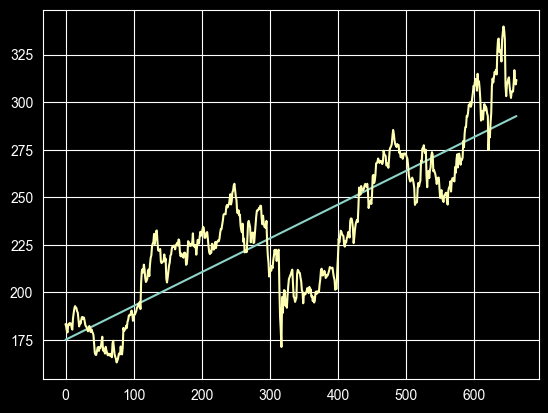

In [27]:
plt.plot(np.arange(len(prices)),trendline)
plt.plot(np.arange(len(prices)),prices)
plt.show()

In [28]:
adf_test(prices_detrended)

ADF Statistics: -2.2789700745714434
p-value 0.17884026454600455
Critical Value (1%) : -3.440
Critical Value (5%) : -2.866
Critical Value (10%) : -2.569


In [29]:
# Using a moving Average to remove the trend

window = 12
prices_ma = prices.rolling(window=window).mean()
prices_detrended = prices - prices_ma
prices_detrended = prices_detrended.dropna()

In [30]:
adf_test(prices_detrended)

ADF Statistics: -8.383395933124167
p-value 2.475194171181375e-13
Critical Value (1%) : -3.440
Critical Value (5%) : -2.866
Critical Value (10%) : -2.569


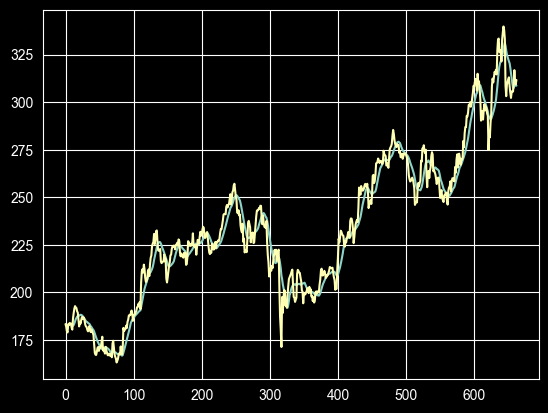

In [31]:
plt.plot(np.arange(len(prices)),prices_ma)
plt.plot(np.arange(len(prices)),prices)
plt.show()

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal Decomposition using moving average
decomposition = seasonal_decompose(prices,model="additive",period=30)
prices_adjusted = prices/decomposition.seasonal
prices_adjusted = prices_adjusted.dropna()

In [33]:
adf_test(prices_adjusted)

ADF Statistics: -7.973195594121352
p-value 2.7460607023241244e-12
Critical Value (1%) : -3.441
Critical Value (5%) : -2.866
Critical Value (10%) : -2.569


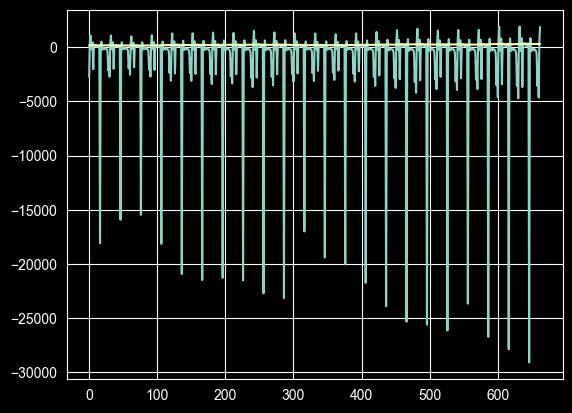

In [34]:
plt.plot(np.arange(len(prices)),prices_adjusted)
plt.plot(np.arange(len(prices)),prices)
plt.show()

# White Noise & Random Walk

**White Noise** : No Pattern,trend or seasonality
* Same Mean
* Constant Variance
* No auto Correlation
* Completely Random --> Unpredictable

**Random Walk** : Cumulative Pattern

**$y_t$ = $y_{t-1}$ + $ \epsilon_t $**

* mean and variance change over time
* first difference is stationary
* First we have to make it Stationary then only we can predict it

**Identifying White Noise & Random Walk**

* Visually
* ACF & PACF
* Ljung Box Test : it is use to check auto correlation

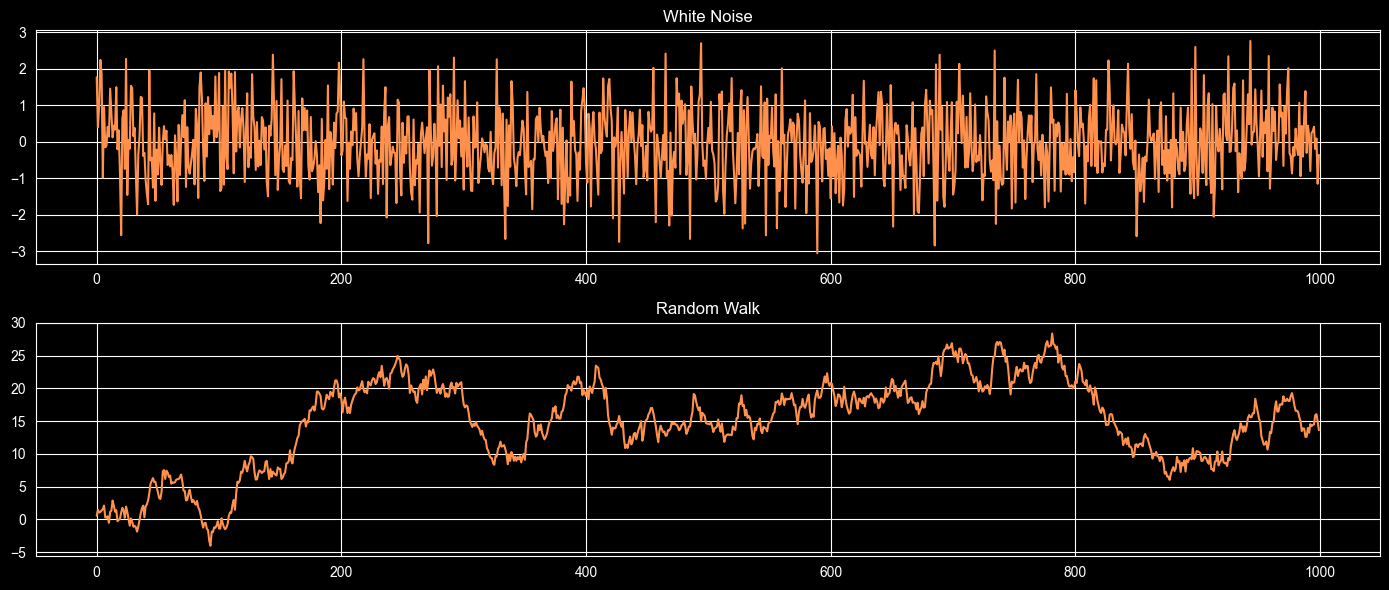


Ljung-Box Test for White Noise:
      lb_stat  lb_pvalue
10  14.025574   0.171828

Ljung-Box Test for Random Walk:
        lb_stat  lb_pvalue
10  8828.660312        0.0


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# generating White Noise and Random Walk for comparison
np.random.seed(0)
n = 1000

# White Noise
white_noise = np.random.normal(0,1,n)

# Random Walk
random_shocks = np.random.normal(0,1,n)
random_walk = np.cumsum(random_shocks)

# Plotting the series
plt.figure(figsize=(14,6))

plt.subplot(2, 1, 1)
plt.plot(white_noise,color = '#FF914D')
plt.title("White Noise")

plt.subplot(2, 1, 2)
plt.plot(random_walk,color = '#FF914D')
plt.title("Random Walk")

plt.tight_layout()
plt.show()

# Ljung-Box-Test
print("\nLjung-Box Test for White Noise:")
lb_test_white_noise = acorr_ljungbox(white_noise,lags=[10],return_df=True)
print(lb_test_white_noise)

print("\nLjung-Box Test for Random Walk:")
lb_test_random_walk = acorr_ljungbox(random_walk,lags=[10],return_df=True)
print(lb_test_random_walk)

# TimeSeries Forecasting Models

**Univariate(Single Variable)**

1. Autoregressive (AR)
2. Moving Average (MA)
3. Autoregressive Moving Average (ARMA)
4. Autoregressive Integrated Moving Average (ARIMA)
5. Seasonal Autoregressive Integrated Moving Average (SARIMA)

**Multivariate(Multiple Variable)**

6. Vector Autoregressive (VAR)
7. Vector Moving Average (VMA)
8. Vector Autoregressive Moving Average (VARMA)
9. Vector Autoregressive Integrated Moving Average (VARIMA)

# 1. Autoregressive (AR)

* Uses past values to predict Future
* Order of AR model is denoted by p
* p = number of lagged observations
* $AR_p$ : $y_t$ = c + $\phi_1$$y_{t-1}$ + $\phi_2$$y_{t-2}$ + ...... + $\phi_p$$y_{t-p}$ + $\epsilon_{t}$
* $\epsilon_{t}$ = white noise
* c = constant
* $y_{t-1}$ , $y_{t-2}$ are the past values

# 2. Moving Average (MA)

* Uses past error terms (residual)
* Order of MA model is denoted by q
* q = number of lagged error terms
* $MA_q$ : $y_t$ = $\epsilon_{t}$ + $\theta_1$$\epsilon_{t-1}$ + $\theta_2$$\epsilon_{t-2}$ + ...... + $\theta_q$$\epsilon_{t-q}$
* $\epsilon_{t}$ = white noise
* c = constant
* $y_{t-1}$ , $y_{t-2}$ are the past values

# 3. Autoregressive Moving Average (ARMA)

* Combines AR & MA model for forecasting
* Captures both temporal dependencies and error
* Order of ARMA model is denoted by (p,q)
* $ARMA_{pq}$ : $y_t$ = $\phi_1$$y_{t-1}$ + $\phi_2$$y_{t-2}$ + ...... + $\phi_p$$y_{t-p}$ + $\epsilon_{t}$ + $\theta_1$$\epsilon_{t-1}$ + $\theta_2$$\epsilon_{t-2}$ + ...... + $\theta_q$$\epsilon_{t-q}$
* $\epsilon_{t}$ = white noise
* c = constant
* $y_{t-1}$ , $y_{t-2}$ are the past values

# 4. Autoregressive Integrates Moving Average (ARIMA)

* I part involves differencing orders
* ARIMA (p,d,q)
* ARIMA(1,1,1)
* AR(1)
* differencing = 1st order
* MA(1)
* $\delta$$y_t$ = $\phi_1$$\delta$$y_{t-1}$ + $\phi_2$$\delta$$y_{t-2}$ + ...... + $\phi_p$$\delta$$y_{t-p}$ + $\epsilon_{t}$ + $\theta_1$$\epsilon_{t-1}$ + $\theta_2$$\epsilon_{t-2}$ + ...... + $\theta_q$$\epsilon_{t-q}$

# 5. Seasonal Autoregressive Integrates Moving Average (SARIMA)

* order SARIMA(p,d,q)(P,D,Q)m
* (p,d,q) = order of ARIMA
* (P,D,Q) = order of seasonal part
* m = period

*Multivariate uses multiple time series & their dependencies on each other to predict future values*

**Granger Causality Test**

* checks if X causes Y or not
* One time series can predict another time series or not
* If today's Apple Stock Price can help predict tomorrow's Tesla Stock Price

# AR Model

In [36]:
# making data stationary before model fitting
stock_data = yf.download('AAPL',start='2023-01-01')

apple_price_stationary = stock_data['Close'].diff().dropna()

# Split the data into training and testing datasets
train_data , test_data = apple_price_stationary[:-30], apple_price_stationary[-30:]

[*********************100%***********************]  1 of 1 completed


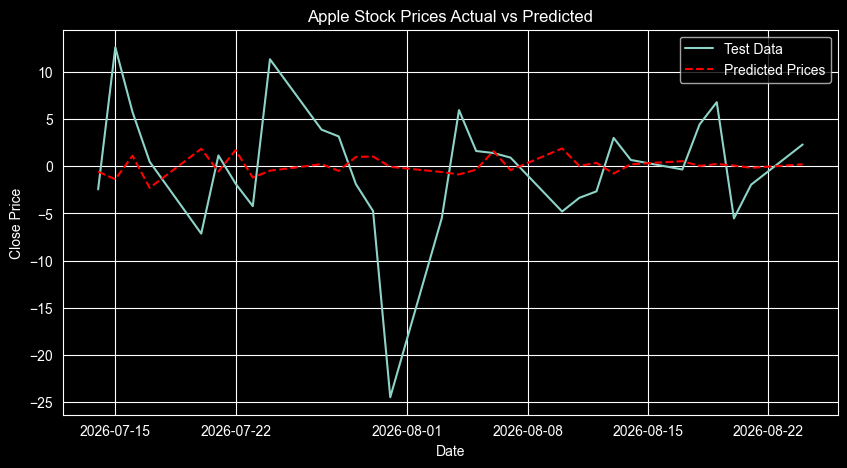

RMSE: 6.83


In [37]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np
import _warnings
warnings.filterwarnings('ignore')

# Fit the autoregression model (AR) to the training data
model = AutoReg(train_data,lags=30)
model_fit = model.fit()

# Make prediction on test data
predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)

# Plot the actual vs predicted values

plt.figure(figsize=(10,5))
plt.plot(test_data.index,test_data,label='Test Data')
plt.plot(test_data.index,predictions,color = 'red' , linestyle='--' ,label='Predicted Prices')
plt.title('Apple Stock Prices Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating Model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data,predictions)),2)
print('RMSE:',rmse)

# MA Model

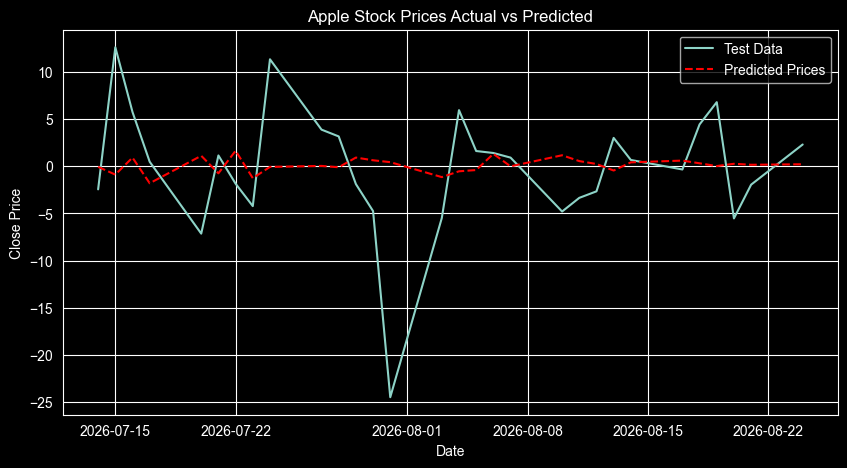

RMSE: 6.75


In [38]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the moving average model to training data
model = ARIMA(train_data,order=(0,0,30))
model_fit = model.fit()

# make prediction on the test data
predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)

# Plot the actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index,test_data,label='Test Data')
plt.plot(test_data.index,predictions,color = 'red' , linestyle='--' ,label='Predicted Prices')
plt.title('Apple Stock Prices Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating Model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data,predictions)),2)
print('RMSE:',rmse)

# ARMA Model

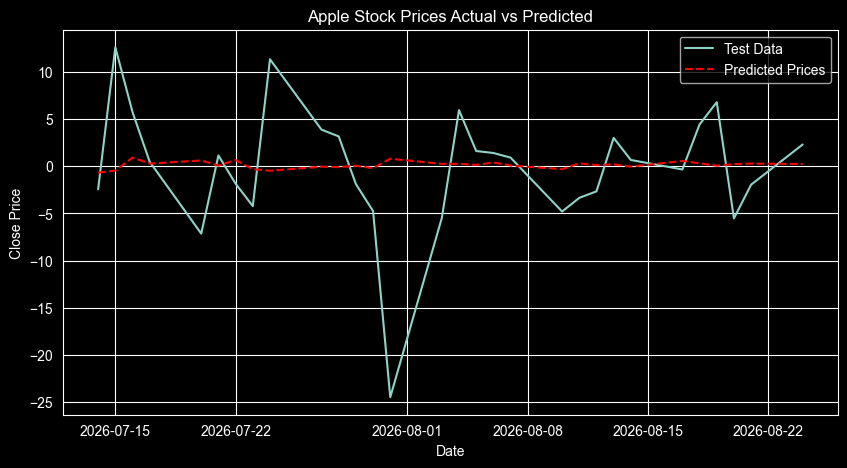

RMSE: 6.67


In [39]:
model = ARIMA(train_data,order=(7,0,7))
model_fit = model.fit()

# make prediction on the test data
predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)

# Plot the actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index,test_data,label='Test Data')
plt.plot(test_data.index,predictions,color = 'red' , linestyle='--' ,label='Predicted Prices')
plt.title('Apple Stock Prices Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating Model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data,predictions)),2)
print('RMSE:',rmse)

# ARIMA Model

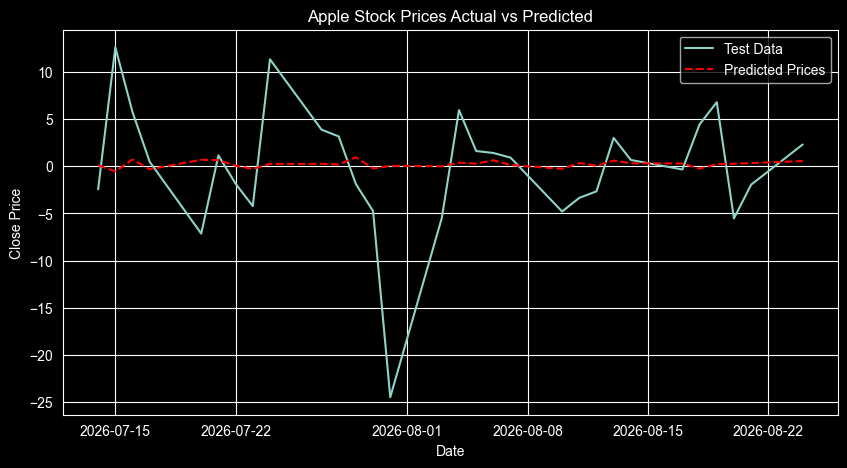

RMSE: 6.54


In [40]:
model = ARIMA(train_data,order=(7,1,7))
model_fit = model.fit()

# make prediction on the test data
predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)

# Plot the actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index,test_data,label='Test Data')
plt.plot(test_data.index,predictions,color = 'red' , linestyle='--' ,label='Predicted Prices')
plt.title('Apple Stock Prices Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating Model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data,predictions)),2)
print('RMSE:',rmse)

# SARIMA Model

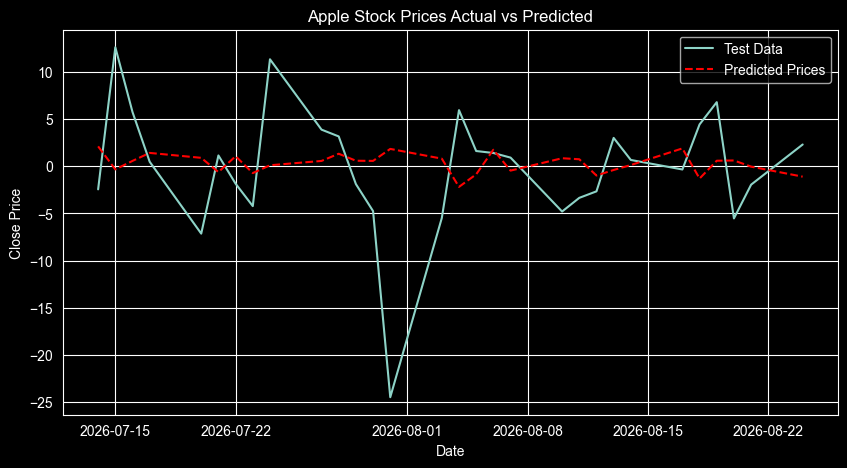

RMSE: 7.03


In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

p,d,q = 7,1,7
P,D,Q,s = 1,1,1,45

model = SARIMAX(train_data,order=(p,d,q),seasonal_order=(P,D,Q,s))
model_fit = model.fit()

# make prediction on the test data
predictions = model_fit.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)

# Plot the actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index,test_data,label='Test Data')
plt.plot(test_data.index,predictions,color = 'red' , linestyle='--' ,label='Predicted Prices')
plt.title('Apple Stock Prices Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating Model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data,predictions)),2)
print('RMSE:',rmse)

# Vector Models

In [42]:
tsla_data = yf.download('TSLA',start='2023-01-01')
stock_data['TSLA_Close'] = tsla_data['Close']
stock_data['APPL_Close'] = stock_data['Close'].shift()
stock_data.dropna(inplace=True)

from statsmodels.tsa.stattools import grangercausalitytests

# perform Granger-Causality test
grangercausalitytests(stock_data[['APPL_Close','TSLA_Close']].dropna(),maxlag=[14])
print()

[*********************100%***********************]  1 of 1 completed


Granger Causality
number of lags (no zero) 14
ssr based F test:         F=9.5013  , p=0.0000  , df_denom=869, df_num=14
ssr based chi2 test:   chi2=137.4567, p=0.0000  , df=14
likelihood ratio test: chi2=127.9002, p=0.0000  , df=14
parameter F test:         F=9.5013  , p=0.0000  , df_denom=869, df_num=14



In [43]:
data = stock_data[['APPL_Close','TSLA_Close']].diff().dropna()
train_data,test_data = data[:-14],data[-14:]

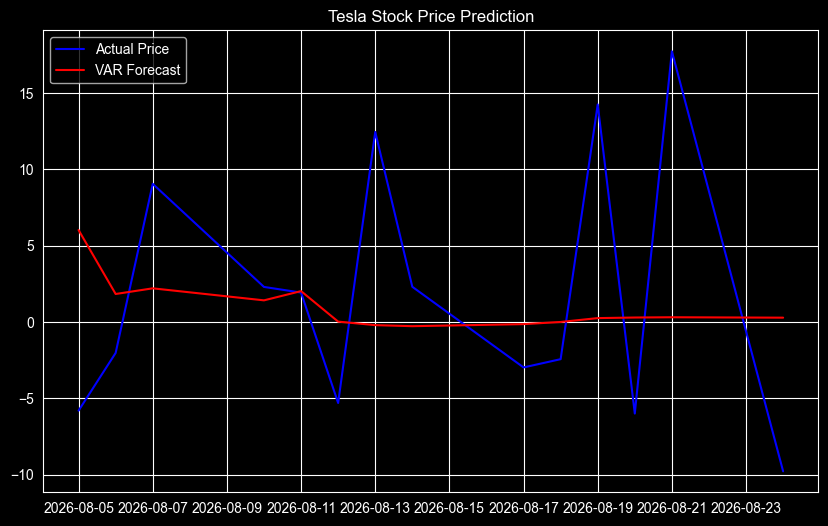

RMSE: 8.66


In [44]:
from statsmodels.tsa.api import VAR,VARMAX
import pandas as pd

# VAR
model = VAR(train_data)
result = model.fit(maxlags=7)
predictions = result.forecast(train_data.values[-result.k_ar:],steps=len(test_data))

predictions = pd.DataFrame(predictions,index = test_data.index,columns = test_data.columns)
plt.figure(figsize=(10,6))
plt.plot(test_data.index,test_data['TSLA_Close'],label='Actual Price',color = 'blue')
plt.plot(test_data.index,predictions['TSLA_Close'],label='VAR Forecast',color = 'red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'],predictions['TSLA_Close'])),2)
print('RMSE:',rmse)

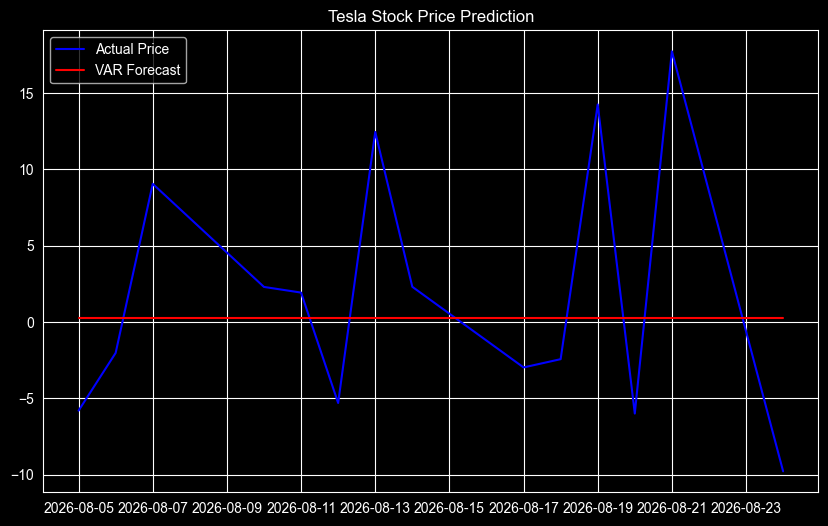

RMSE: 8.32


In [45]:
# VARMAX
model = VARMAX(train_data,order = (0,14))
result = model.fit()
predictions = result.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)


plt.figure(figsize=(10,6))
plt.plot(test_data.index,test_data['TSLA_Close'],label='Actual Price',color = 'blue')
plt.plot(test_data.index,predictions['TSLA_Close'],label='VAR Forecast',color = 'red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'],predictions['TSLA_Close'])),2)
print('RMSE:',rmse)

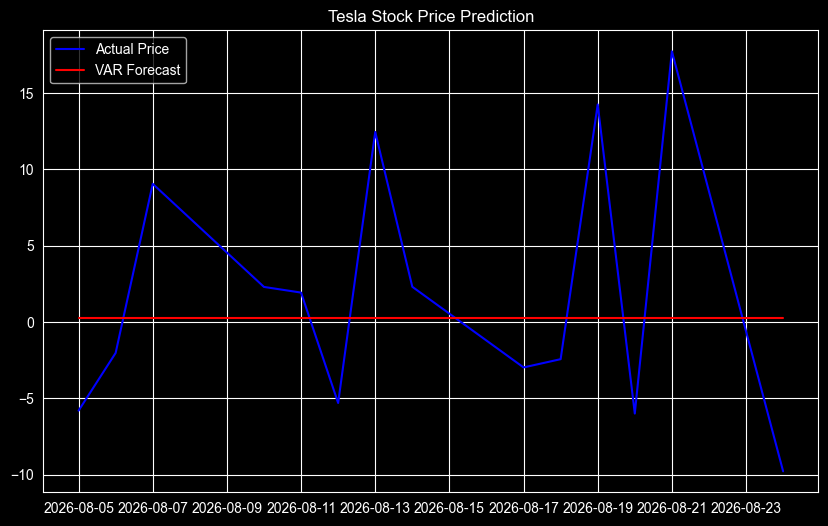

RMSE: 8.32


In [46]:
# VARIMA
model = VARMAX(train_data,order = (14,14))
result = model.fit()
predictions = result.predict(
    start = len(train_data),
    end = len(train_data) + len(test_data) - 1,
    dynamic = False
)


plt.figure(figsize=(10,6))
plt.plot(test_data.index,test_data['TSLA_Close'],label='Actual Price',color = 'blue')
plt.plot(test_data.index,predictions['TSLA_Close'],label='VAR Forecast',color = 'red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'],predictions['TSLA_Close'])),2)
print('RMSE:',rmse)

# Smoothing Methods

* Importnace of Smoothing
* Moving Average (SMA , WMA , EMA)
* Exponential Smoothing : Single E.S.(suitable for data with no trend or seasonality) , Double E.S. (Holt's Linear) Data with trend, Triple E.S. (Holt's Winters) Data with trend & seasonality
* Noise Reduction
* Good for forecasting high fluctuation time series data
* Trend Identification

**Moving Average**

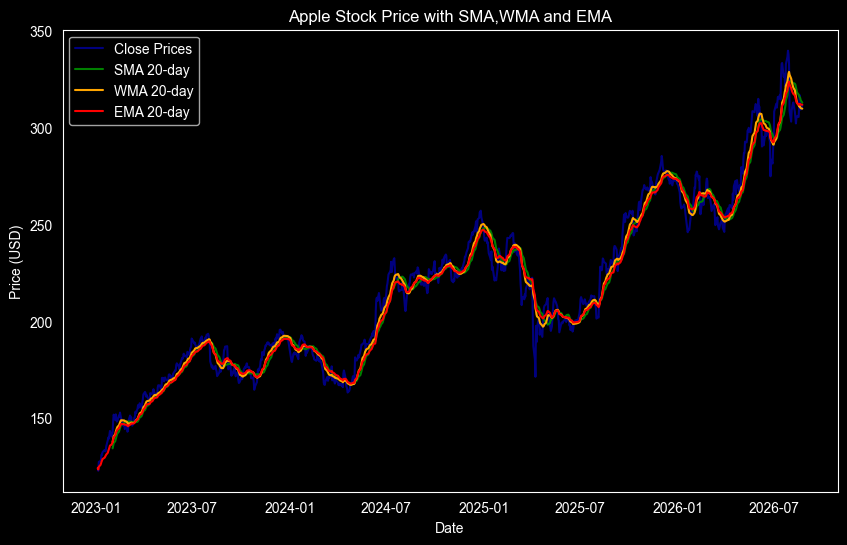

In [47]:
window_size = 20
stock_data['SMA'] = stock_data['Close'].rolling(window = window_size).mean()

# Calculate Weighted Moving Average (WMA)
weights = np.arange(1,window_size+1)
stock_data['WMA'] = stock_data['Close'].rolling(window=window_size).apply(lambda prices: np.dot(prices, weights) / weights.sum(),raw=True)

# Calculate Exponential Moving Average (EMA)
stock_data['EMA'] = stock_data['Close'].ewm(span=window_size).mean()

# Plotting
plt.figure(figsize=(10,6))
plt.plot(stock_data['Close'],label='Close Prices',color = 'blue',alpha = 0.5)
plt.plot(stock_data['SMA'],label=f'SMA {window_size}-day',color = 'green')
plt.plot(stock_data['WMA'],label=f'WMA {window_size}-day',color = 'orange')
plt.plot(stock_data['EMA'],label=f'EMA {window_size}-day',color = 'red')

plt.title('Apple Stock Price with SMA,WMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

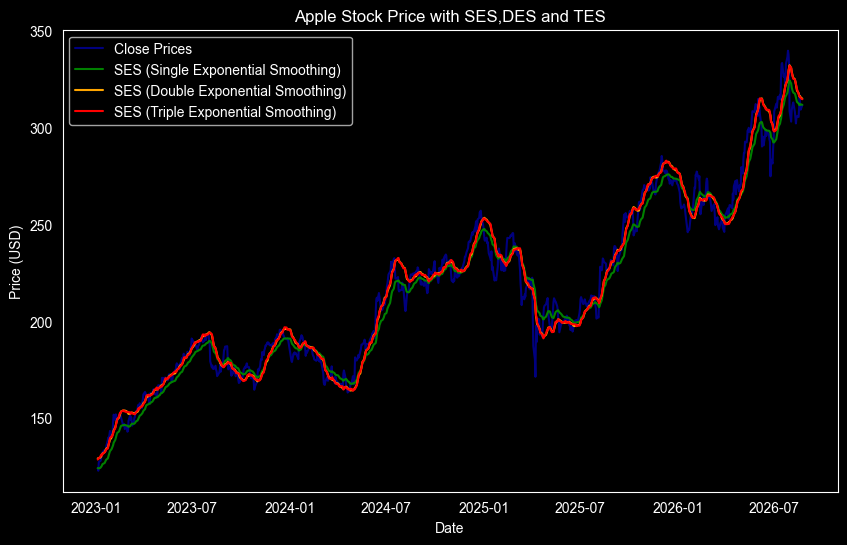

In [48]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing

close_prices = stock_data['Close']
ses_model = SimpleExpSmoothing(close_prices).fit(smoothing_level=0.1)
stock_data['SES'] = ses_model.fittedvalues

# Double Exponential Smoothing (DES) - Holt's linear trend model
des_model = ExponentialSmoothing(close_prices,trend = 'add').fit(smoothing_level=0.1)
stock_data['DES'] = des_model.fittedvalues

# Triple Exponential Smoothing (TES) - Holt-Winters method
tes_model = ExponentialSmoothing(close_prices,trend = 'add',seasonal='add',seasonal_periods=12).fit(smoothing_level=0.1)
stock_data['TES'] = tes_model.fittedvalues

# Plotting
plt.figure(figsize=(10,6))
plt.plot(stock_data['Close'],label='Close Prices',color = 'blue',alpha = 0.5)
plt.plot(stock_data['SES'],label='SES (Single Exponential Smoothing)',color = 'green')
plt.plot(stock_data['DES'],label='SES (Double Exponential Smoothing)',color = 'orange')
plt.plot(stock_data['TES'],label='SES (Triple Exponential Smoothing)',color = 'red')

plt.title('Apple Stock Price with SES,DES and TES')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

# ACF & PACF Plot

Autocorrelation Function & Partial Autocorrelation Function

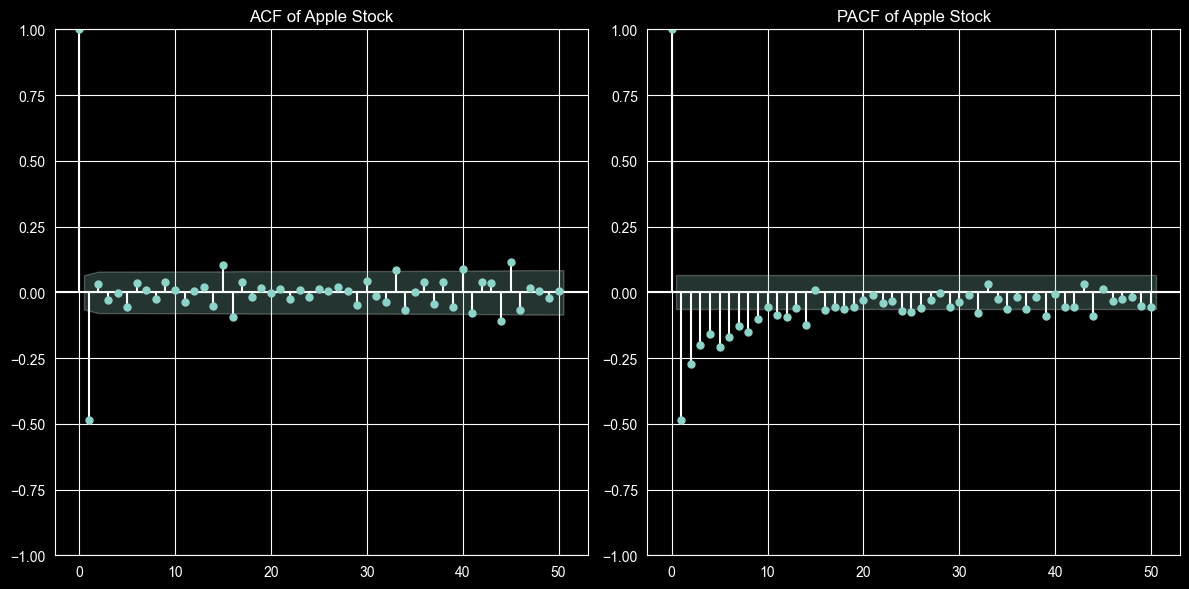

In [49]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plt.figure(figsize=(12,6))

# ACF Plot
plt.subplot(1,2,1)
plot_acf(stock_data['Close'].diff().diff().dropna(),ax=plt.gca(),lags=50)
plt.title('ACF of Apple Stock')

# PACF Plot
plt.subplot(1,2,2)
plot_pacf(stock_data['Close'].diff().diff().dropna(),ax=plt.gca(),lags=50,method='ywm')
plt.title('PACF of Apple Stock')

plt.tight_layout()
plt.show()

# Model Evaluation Metrics

1. MAE
2. MSE
3. RMSE
4. MAPE
5. AIC
6. BIC

**1. MAE (Mean Absolute Error)**

* It measures the average magnitude of errors in prediction without considering direction
* Treats all errors equal
* Less sensitive to outliers

**2. MSE (Mean Square Error)**

* It measures the average of square of errors
* Emphasizing more on large errors
* Sensitive to outliers

**3. RMSE (Root Mean Square Error)**

* It measures the root of average of square of errors

**4. MAPE (Mean Absolute Percentage Error)**

* It measures the percentage of MAE

**AIC(Akaike Information Criteria) & BIC (Bayesian Information Criteria)**

* are used in time series models like AR,MA,ARIMA,SARIMA
* Decision Criteria : lowest AIC or BIC
* can be used to compare different models depending upon the AIC and BIC (lowest value)

In [52]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(test_data,predictions)
print(f'Mean Absolute Error:{mae}')

# 2. Mean Square Error (MSE)
mse = mean_squared_error(test_data,predictions)
print(f'Mean Square Error:{mse}')

# 3. Root Mean Square Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Square Error:{rmse}')

#4. Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((np.array(test_data) - np.array(predictions)) / np.array(test_data))) * 100
print(f'Mean Absolute Percentage Error:{mape}%')

# aic and bic
aic = model_fit.aic
bic = model_fit.bic


print(f'Akaike Information Criterion (AIC): {aic}')
print(f'Bayesian Information Criterion (BIC): {bic}')

Mean Absolute Error:4.905336575138667
Mean Square Error:41.40556578402632
Root Mean Square Error:6.434715672353078
Mean Absolute Percentage Error:99.95633124205966%
Akaike Information Criterion (AIC): 4597.149214364754
Bayesian Information Criterion (BIC): 4677.535900787194
